# Asynchronous Friedkin-Johnsen Dynamics and Wake-Up Centrality

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd
import cvxpy as cp

## Network Definition

### Unweighted Synthetic Networks

Watts-Strogatz Graph

[[0.         0.         0.         ... 0.         0.         0.2       ]
 [0.         0.         0.33333333 ... 0.         0.         0.        ]
 [0.         0.2        0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.33333333 0.         0.         ... 0.         0.         0.        ]]


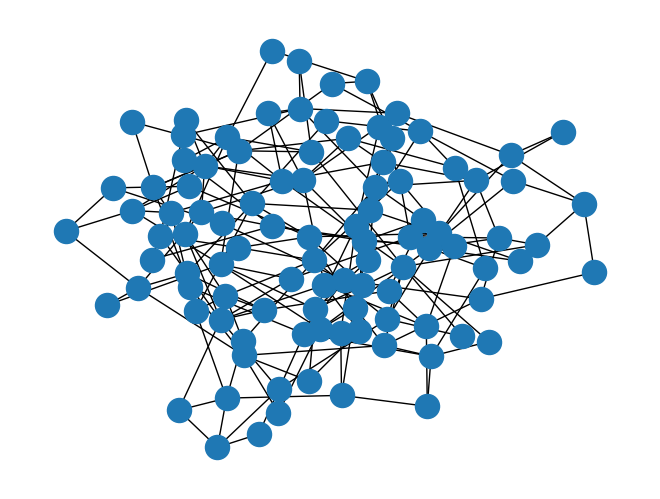

In [224]:
N= 100
g = nx.watts_strogatz_graph(N,4,.7)
W = nx.adjacency_matrix(g)
W = W.toarray()
v = np.diag((1/(W.sum(axis=1)+1)))
A = v@W
print(A)
G = nx.Graph()
for i in range(N): 
 for j in range(N): 
   if A[i][j] != 0: 
      G.add_edge(i,j) 
      G.add_edge(j,i) 
nx.draw(G) 
plt.show() 

Erdos-Renyi Graph

[[0.         0.02564103 0.02564103 ... 0.         0.         0.        ]
 [0.03448276 0.         0.         ... 0.         0.03448276 0.        ]
 [0.02631579 0.         0.         ... 0.         0.02631579 0.        ]
 ...
 [0.         0.         0.         ... 0.         0.03225806 0.        ]
 [0.         0.02857143 0.02857143 ... 0.02857143 0.         0.02857143]
 [0.         0.         0.         ... 0.         0.03125    0.        ]]


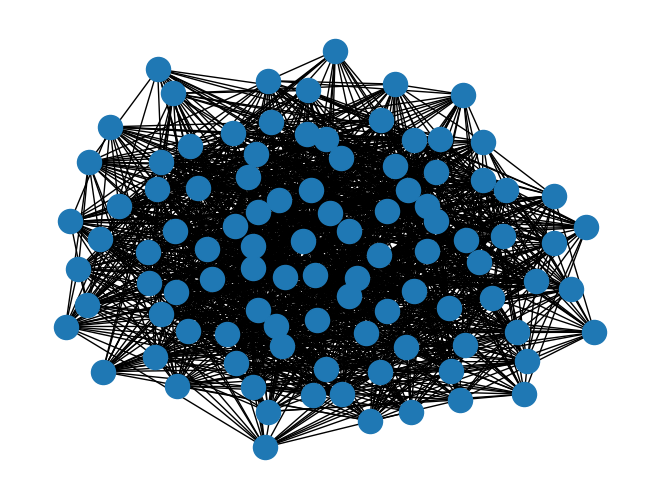

In [357]:
N= 100
g = nx.erdos_renyi_graph(N,.3,28)
W = nx.adjacency_matrix(g)
W = W.toarray()
v = np.diag((1/(W.sum(axis=1)+1)))
A = v@W
print(A)
G = nx.Graph()
for i in range(N): 
 for j in range(N): 
   if A[i][j] != 0: 
      G.add_edge(i,j) 
      G.add_edge(j,i) 
nx.draw(G) 
plt.show() 

### Weighted Synthetic Network

[[0.         0.         0.05110056 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.0685326 ]
 [0.04729895 0.         0.         ... 0.         0.         0.00956057]
 ...
 [0.         0.         0.         ... 0.         0.05650124 0.        ]
 [0.         0.         0.         ... 0.0126475  0.         0.00696846]
 [0.         0.03871056 0.04339442 ... 0.         0.02717745 0.        ]]


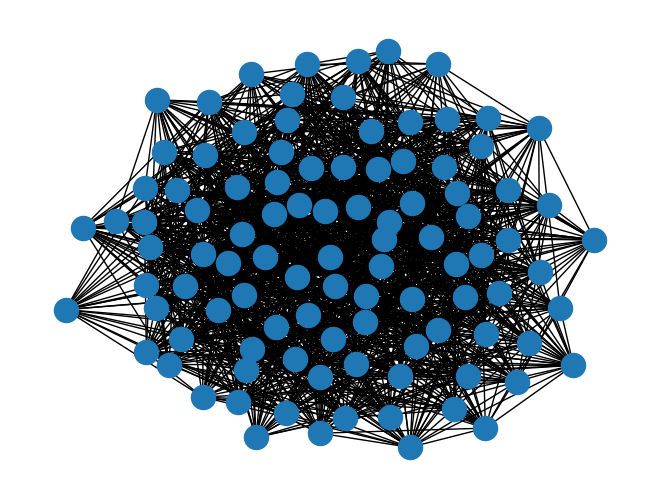

In [ ]:
N= 100
g = nx.erdos_renyi_graph(N,.3,15)
W_mask = nx.adjacency_matrix(g)
W_mask = W_mask.toarray()
W_weights = np.random.rand(N,N)
W = W_weights*W_mask
v = np.diag((1/(W.sum(axis=1)+1)))
A = v@W
print(A)
G = nx.Graph()
for i in range(N): 
 for j in range(N): 
   if A[i][j] != 0: 
      G.add_edge(i,j, weight = A[i][j]) 
nx.draw(G) 
plt.show() 

### Malawi Network

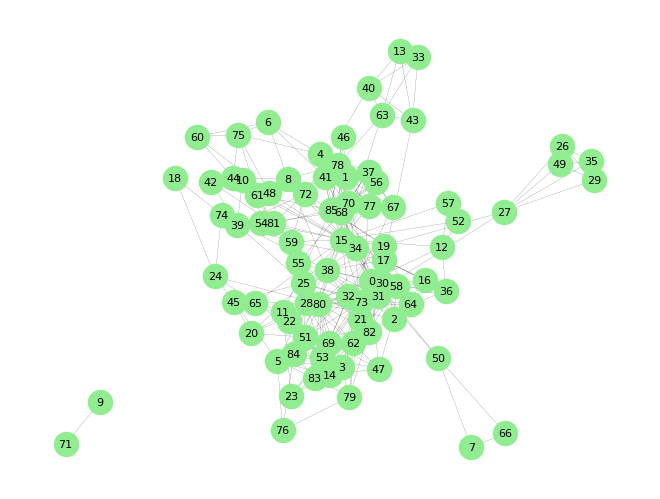

In [252]:
# import data from file
malawi_data = pd.read_excel("malawi_edges.xlsx")
malawi_data.groupby(['Source', 'Target']).size() .sort_values(ascending=False).reset_index(name='weight')
# create network structure
network = malawi_data.groupby(['Source', 'Target']).size() .sort_values(ascending=False) .reset_index(name='weight') #.drop_duplicates(subset='Target')
network["normalized_W"]=(network["weight"]-network["weight"].min())/(network["weight"].max()-network["weight"].min())+0.1
# collect all the nodes
nodes = pd.concat([network['Source'],network['Target']]).drop_duplicates().sort_values()
N = len(nodes)
# adj matrix
A_global = np.zeros((N,N)) #weighted
W = np.zeros((N,N)) #undirected adj matrix
for i in range(0,N):
    for j in range(0,N):
        if len(network[((network['Source'].values==i+1)&(network['Target'].values==j+1))])!=0:
            A_global[i,j]= network.loc[((network['Source'].values==i+1)&(network['Target'].values==j+1)), 'normalized_W'].iloc[0]
            W[i,j]=1
            W[j,i]=1
G = nx.Graph()
for i in range(N): 
 for j in range(N): 
   if W[i][j] != 0: 
      G.add_edge(i,j) 
      G.add_edge(j,i) 
pos = nx.spring_layout(G,seed=30, k=.3)
nx.draw(G,pos=pos,with_labels=True, node_size=300, font_size=8,node_color='lightgreen', width=.1) 
plt.show() 

[[0.         0.         0.05110056 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.0685326 ]
 [0.04813165 0.         0.         ... 0.         0.         0.00972889]
 ...
 [0.         0.         0.         ... 0.         0.06007801 0.        ]
 [0.         0.         0.         ... 0.0126475  0.         0.00696846]
 [0.         0.03925694 0.04400691 ... 0.         0.02756105 0.        ]]


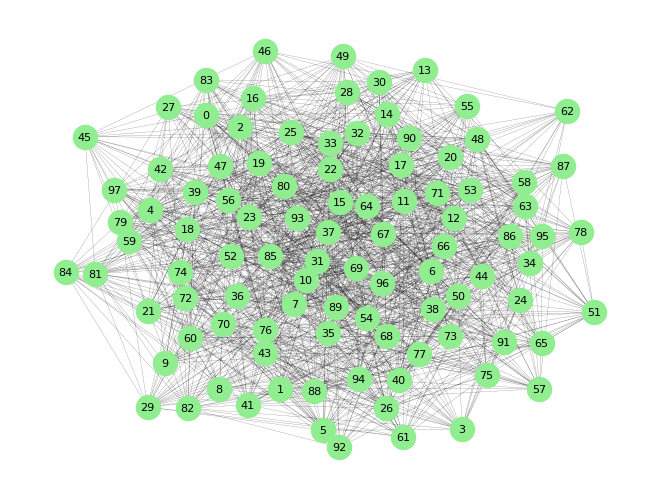

In [313]:
# define the biggest connected component 
W_connected= np.delete(W, [9, 71], 0)
W_connected = np.delete(W_connected, [9,71], 1)
#A = (W_connected.T/ W_connected.sum(axis=1)).T
v = np.diag((1/(W_connected.sum(axis=1)+1)))
A = v@W_connected
print(A)
N = np.shape(W_connected)[0]
G = nx.Graph()
for i in range(N): 
 for j in range(N): 
   if A[i][j] != 0: 
      G.add_edge(i,j) 
pos = nx.spring_layout(G,seed=1, k=.3)
#pos = nx.kamada_kawai_layout(G)
nx.draw(G,pos=pos,with_labels=True, node_size=300, font_size=8,node_color='lightgreen', width=.1) 
plt.savefig('malawi_network')
plt.show() 

### Regions Network

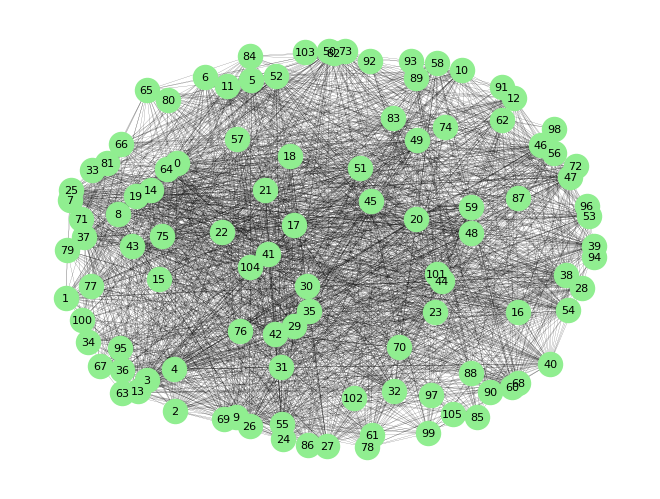

In [388]:
province = pd.read_csv('Ad_matrix_province.csv', index_col=0)
Prov = province.values
non_neg_idxs = np.arange(Prov.shape[0])[Prov.sum(axis=1) != 0]
W = Prov[np.ix_(non_neg_idxs,non_neg_idxs)]
v = np.diag((1/(W.sum(axis=0)+1)))
A = v@W
N = np.shape(A)[0]
G = nx.Graph()
for i in range(N): 
 for j in range(N): 
   if A[i][j] != 0: 
      G.add_edge(i,j, weight = A[i][j]) 

pos = nx.spring_layout(G,seed=1, k=.3)
#pos = nx.kamada_kawai_layout(G)
nx.draw(G,pos=pos,with_labels=True, node_size=300, font_size=8,node_color='lightgreen', width=.1) 
plt.savefig('malawi_network')
plt.show() 

## Model Definition and Algorithm Implementation

Given a network $G$ with $N$ nodes, let $A$ be the weight matrix associated to the graph. Assume that each agent updates his value asynchronously, i.e. each node updates his value with probability $p_i$. Then, 
$$
\begin{cases} 
x_i(k+1) = \sum_j A_{ij} x_j(k)+b_i \; \text{if chosen}\\
x_i(k+1) = x_i(k) \; \text{otherwise}
\end{cases}
$$
 The expected dynamics value then follows the followinf dynamics equation
 $$ E[X_{k+1}] = [1-p]E[X_k] + [p](AE[X_k]+b)$$
Thus it converges to 
$$E[X_k] \to (I-([1-p]+[p]A))^{-1}[p]b$$
The convergence rate depends is a function of probability vector $p$. Precisely, it is measured by the spectral radius of the matrix associated to the new dynamics $f(p)=\rho([1-p]+[p]A)$. 

Let us recall that $$\rho([1-p]+[p]A) = \begin{array}{ll} &\min \lambda \\ &\text{s.t.} \;([1-p]+[p]A) x \leq \lambda x \\ &\qquad \exists x > 0, x'1=1\\ &\qquad p\geq 0, p'1=1 \end{array}$$

Try to work on *weighted graphs* using 
$$A_{ij} = \frac{W_{ij}}{\sum_m W_{im}+1}$$
where $W$ is the weighted adjacency matrix. $A$ will be substochastic by construction 

### Update Dynamics Definition

In [167]:
def avg_update_step(X, A ,b, p):
    N = np.shape(A)[0]
    X = (np.ones(N)-p)*np.eye(N)@X + p*np.eye(N)@(A@X+b)
    return X

In [168]:
def traditional_update_step(X, A ,b, p):
    X = A@X+b
    return X

In [169]:
def equilibrium(X,A,b):
    X_eq = np.linalg.inv(np.eye(N)-A)@b
    return X_eq

In [170]:
def spectral_radius(M: np.ndarray) -> float:
    vals = np.linalg.eigvals(M)
    return float(np.max(np.abs(vals))) #spectral radius is max eigenvalue

def dominant_eigvec_nonneg(M: np.ndarray) -> np.ndarray:
    vals, vecs = np.linalg.eig(M)
    idx = np.argmax(np.abs(vals))
    vect = np.real(vecs[:, idx])
    s = vect.sum()
    return vect / s #normalized such that sum over x is 1

def build_M(A: np.ndarray, p: np.ndarray) -> np.ndarray:
    """M(p) = Diag(1-p) + Diag(p) @ A"""
    p = np.asarray(p, float).ravel()
    Dp = np.diag(p)
    I_minus_p = np.diag(1.0 - p)
    return I_minus_p + Dp @ A


### Optimization problem via SLP

Linearize introducing the following envelopment. 
Let us introduce the ausiliary variables
$$w_{ij}=p_i*x_j \qquad t_i = \lambda_i x_i$$
Now the constraint $$x +(A-I)diag(p)x \leq \lambda x$$ can be rewritten as $$x_i +\sum_j A_{ij}*w_{ij} - w_{ii} \leq t_i$$

In [171]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

def M_of_p(A, p):
    n = A.shape[0]
    return np.diag(np.ones(n) - p) + np.diag(p) @ A

def init_lambda(A, p, x, eps_x=1e-12):
    M = M_of_p(A, p)
    lam = (M @ x) / np.maximum(x, eps_x)
    
    return float(np.max(lam))

def project_to_simplex(v):
    v = np.asarray(v, float).ravel()
    n = v.size
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, n + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1.0) / (rho + 1.0)
    w = np.maximum(v - theta, 0.0)
    return w

def solve_gurobi_bilinear(
    A,
    p0=None,
    x0=None,
    simplex_p=True,          # True: impone sum p = 1
    L_lambda=0.0,
    U_lambda=None,           # se None, viene stimato
    time_limit=20,
    mip_gap=None,
    verbose=True
):
    """
    Risolve il problema bilineare con Gurobi (NonConvex=2).
    Ritorna p, x, lambda.
    """
    A = np.asarray(A, float)
    n = A.shape[0]

    # --- stima opzionale di U_lambda per dare bounds sensati al termine bilineare lambda*x_i --- #
    if p0 is None:
        p_init = np.ones(n)  #if simplex_p else np.clip(np.ones(n)/n, 0, 1)
    else:
        p_init = project_to_simplex(p0) if simplex_p else np.clip(np.asarray(p0, float), 0, 1)

    if x0 is None:
        x_init = np.ones(n) / n
    else:
        x_init = np.maximum(np.asarray(x0, float).ravel(), 0.0)
        sx = x_init.sum()
        x_init = x_init / (sx if sx > 0 else 1.0)

    lam_feas = init_lambda(A, p_init, x_init)
    if U_lambda is None:
        U_lambda = max(1.0, 1.2 * lam_feas)  # margine prudenziale

    # --- modello --- #
    env = None  # usa ambiente di default
    m = gp.Model("bilinear_MpAx_le_lamx", env=env)
    m.Params.NonConvex = 2                  # <-- necessario per termini bilineari
    if time_limit is not None:
        m.Params.TimeLimit = float(time_limit)
    if mip_gap is not None:
        m.Params.MIPGap = float(mip_gap)
    m.Params.OutputFlag = 1 if verbose else 0

    # variabili
    p = m.addVars(n, lb=1e-3, ub=1.0, name="p")
    x = m.addVars(n, lb=1e-3, ub=1.0, name="x")   # ub=1 è coerente con sum x = 1
    lam = m.addVar(lb=L_lambda, ub=U_lambda, name="lambda")

    # simplex
    if simplex_p:
        m.addConstr(gp.quicksum(p[i] for i in range(n)) == 1.0, name="sum_p")
    m.addConstr(gp.quicksum(x[j] for j in range(n)) == 1.0, name="sum_x")

    # vincoli bilineari, riga per riga:
    # (1 - p_i) x_i + p_i * sum_j A_ij x_j <= lambda * x_i
    # -> x_i - p_i*x_i + sum_j (A_ij * p_i*x_j) <= lam * x_i
    for i in range(n):
        # costruiamo una QuadExpr
        expr = gp.QuadExpr()
        expr.add(x[i])                       # x_i
        expr.add(-p[i] * x[i])               # - p_i * x_i
        # parte p_i * (A_i: x)
        row = A[i, :]
        nz = np.nonzero(row)[0]
        for j in nz:
            if row[j] != 0.0:
                expr.add(row[j] * p[i] * x[j])
        # lato destro: lam * x_i  -> portiamolo a sinistra
        expr.add(-lam * x[i])
        m.addQConstr(expr <= 0.0, name=f"row_{i}")

    # obiettivo: minimizzare lambda
    m.setObjective(lam, GRB.MINIMIZE)

    # warm start (facoltativo)
    for i in range(n):
        p[i].Start = float(p_init[i])
        x[i].Start = float(x_init[i])
    lam.Start = lam_feas

    m.optimize()

    if m.Status not in (GRB.OPTIMAL, GRB.SUBOPTIMAL, GRB.TIME_LIMIT):
        raise RuntimeError(f"Gurobi status: {m.Status}")

    # estrai soluzione
    p_sol = np.array([p[i].X for i in range(n)], dtype=float)
    # se servisse, proiettiamo p sul simplex per robustezza numerica
    p_sol = project_to_simplex(p_sol) if simplex_p else np.clip(p_sol, 0.0, 1.0)

    x_sol = np.array([x[j].X for j in range(n)], dtype=float)
    x_sol = np.maximum(x_sol, 0.0)
    sx = x_sol.sum()
    if sx > 0:
        x_sol /= sx

    lam_sol = float(lam.X)

    return p_sol, x_sol, lam_sol

## Simulations

In [389]:
print('spectral radius for synchronous system:', spectral_radius(A))

spectral radius for synchronous system: 0.10801847916660164


In [390]:
# ----- SLP ----- #
p_star_slp, x_star_slp, lambda_star_slp = solve_gurobi_bilinear(A, verbose = False, time_limit=60*25)
print("\n--- RISULTATO SLP ---")
print("p*        =", np.round(p_star_slp, 6))
print("lambda*   =", lambda_star_slp)

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 1500

--- RISULTATO SLP ---
p*        = [0.009248 0.009871 0.009433 0.009182 0.009786 0.009205 0.009432 0.009518
 0.00895  0.009023 0.009208 0.009159 0.009598 0.009718 0.0099   0.009906
 0.009121 0.010464 0.009558 0.009452 0.009649 0.009807 0.009764 0.009679
 0.008952 0.009066 0.00938  0.009551 0.009104 0.009956 0.010137 0.010125
 0.009663 0.009554 0.009678 0.009768 0.00939  0.009548 0.00943  0.009803
 0.009696 0.009641 0.00968  0.009576 0.009635 0.009509 0.009774 0.009676
 0.009804 0.010024 0.009906 0.009523 0.009989 0.009368 0.009357 0.009145
 0.009217 0.009258 0.009364 0.009456 0.009656 0.009588 0.009215 0.00925
 0.008942 0.009189 0.009229 0.009287 0.009592 0.009852 0.009756 0.009774
 0.009344 0.009419 0.009266 0.009287 0.009342 0.009145 0.009074 0.009357
 0.009265 0.009347 0.00912  0.009086 0.009168 0.00908  0.009044 0.009176
 0.009132 0.009078 0.009001 0.00897  0.009052 0.009218 0.009187 0.009221
 0.009038 0.00904

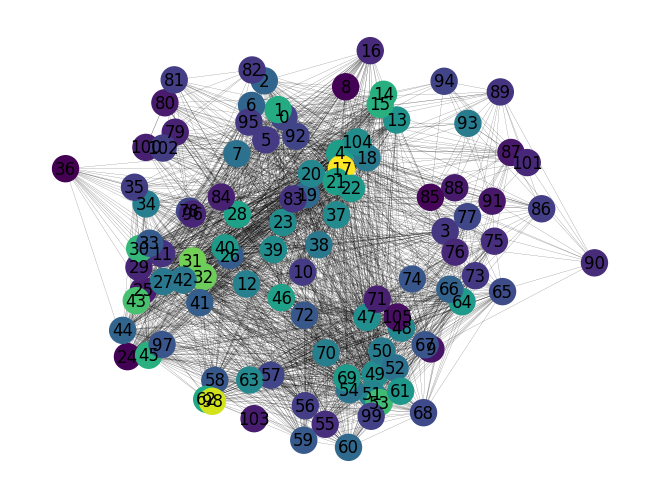

In [391]:
plt.figure(1)
pos = nx.spring_layout(G, seed=12)
nx.draw(G,pos=pos, with_labels=True,node_size=350,node_color=p_star_slp,width=.1)

Comparison between $(\lambda^*)^N$ and spectral radius generated in case of synchronous system. The idea is to compare one single iteration of synchronous model with $N$ steps of asynchrounous one. 

In [392]:
print('lambda* after N iterations of asynchronous dynamics:',lambda_star_slp**N)

lambda* after N iterations of asynchronous dynamics: 0.38869221083624267


### Comparison with Uniform distribution

Comparison between the spectral radius found through our method and the one computed using uniform activation probability $p= 1/n$. A lower spectral radius guarantees faster convergence to the equilibrium.
Uniform distribution is taken as a benchmark as it refers to an asynchronous attivation policy without any extra knowledge on the problem of interest

In [393]:
p_uniform = np.ones(N)/N
M_uniform = build_M(A, p_uniform)
if spectral_radius(M_uniform)>lambda_star_slp:
    lambda_uniform= spectral_radius(M_uniform)
    print('spectral radius in case of uniform activation', lambda_uniform)
    print('relative reduction using weak-up centrality', (lambda_star_slp-lambda_uniform)/lambda_uniform)



spectral radius in case of uniform activation 0.991585079992143
relative reduction using weak-up centrality -0.00046415446541709315


### Comparison with known centrality measures 

_Friedkin Centrality Measure_
$$ c = (I-A)^{-1}[v], \qquad A_{ij} = \frac{W_{ij}}{1+ (W1)_i}, \; v_i = \frac{1}{1+ (W1)_i}$$

spectral radius in case of friedkin influence measure 0.991377576298431
relative reduction using influence cent -0.00020926463890880972
lambda_fried after N iterations of asynchronous dynamics: 0.39934081323063636


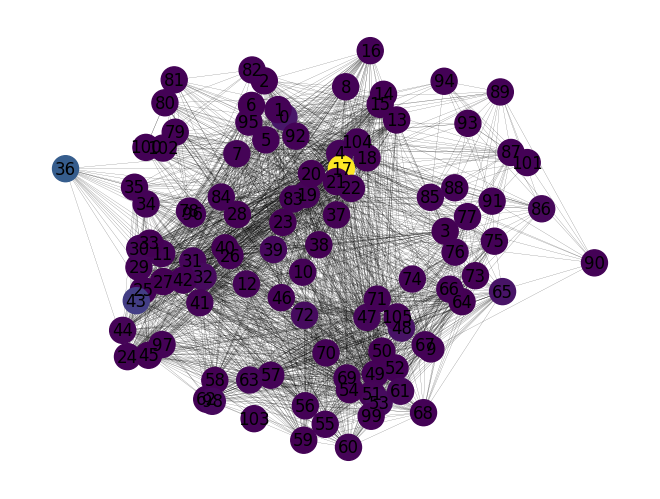

In [394]:
# Friedkin Influence Centrality Measure
invA = np.linalg.inv(np.eye(N)-A)
V = v@invA
fried_c = (1/N)*V.T@np.ones(N) # vector v defined when the network has been created
#fried_c = fried_c / fried_c.sum()
M_fried = build_M(A,fried_c)
lambda_fried = spectral_radius(M_fried)
plt.figure(1)
pos = nx.spring_layout(G, seed=12)
nx.draw(G,pos,with_labels=True,node_size=350,node_color=fried_c,width=.1)
print('spectral radius in case of friedkin influence measure', lambda_fried)
print('relative reduction using influence cent', (lambda_fried-lambda_uniform)/lambda_uniform)
print('lambda_fried after N iterations of asynchronous dynamics:',lambda_fried**N)

In [395]:
degreecent = nx.degree_centrality(G)
val = np.array(list(degreecent.values()))
dcent_color = val / val.sum()
M_degree = build_M(A, dcent_color)
print('spectral radius in case of degree cent', spectral_radius(M_degree))
degree2 = A.sum(axis=1)
degree2 = degree2/degree2.sum()

#plt.figure(1)
#pos = nx.spring_layout(G, seed=28)
#nx.draw(G,pos,with_labels=True,node_size=500,node_color=dcent_color,width=.1)

spectral radius in case of degree cent 0.9993214740469677


In [396]:
ecent = nx.eigenvector_centrality(G)
val = np.array(list(ecent.values()))
ecent_color = val / val.sum()
M_eigen = build_M(A, ecent_color)
print('spectral radius in case of eigenvector cent', spectral_radius(M_eigen))
#plt.figure(1)
#pos = nx.spring_layout(G, seed=28)
#nx.draw(G,pos,with_labels=True,node_size=500,node_color=ecent_color,width=.1)

spectral radius in case of eigenvector cent 0.9999501190065547


In [397]:
pagerankcent = nx.pagerank(G)
val = np.array(list(pagerankcent.values()))
pagerank_color = val/val.sum()
M_pagerank = build_M(A, pagerank_color)
print('spectral radius in case of pagerank cent', spectral_radius(M_pagerank))
#plt.figure(1)
#pos = nx.spring_layout(G, seed=28)
#nx.draw(G,pos=pos,with_labels=True,node_size=500,node_color=pagerank_color,width=.1)

spectral radius in case of pagerank cent 0.9971047334546841


In [398]:
bcent = nx.betweenness_centrality(G,weight='weight')
val = np.array(list(bcent.values()))
bcent_color = val/val.sum()
M_bet = build_M(A, bcent_color)
print('spectral radius in case of betweenness cent', spectral_radius(M_bet))
#plt.figure(1)
#pos = nx.spring_layout(G, seed=28)
#nx.draw(G,pos,with_labels=True,node_size=500,node_color=bcent_color,width=.1)

spectral radius in case of betweenness cent 1.0


In [399]:
ccent = nx.closeness_centrality(G, distance='weight')
val = np.array(list(ccent.values()))
ccent_color = val/val.sum()
M_clos = build_M(A, ccent_color)
print('spectral radius in case of closeness cent', spectral_radius(M_clos))
#plt.figure(1)
#pos = nx.spring_layout(G, seed=28)
#nx.draw(G,pos,with_labels=True,node_size=500,node_color=ccent_color,width=.1)

spectral radius in case of closeness cent 0.9998884873500257


spectral radius in case of harmonic cent 0.9999844274891637
relative reduction using harmonic cent 0.00847062714687812
lambda_h after N iterations of asynchronous dynamics: 0.9983506626528232


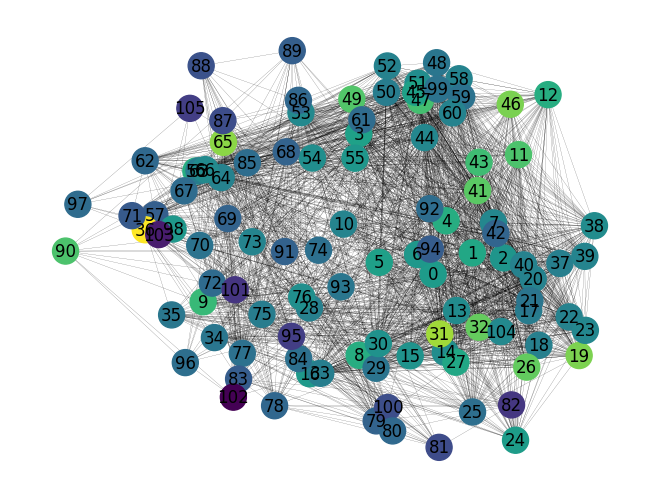

In [400]:
hcent = nx.harmonic_centrality(G, distance= 'weight')
val = np.array(list(hcent.values()))
hcent_color = val/val.sum()
M_harm = build_M(A, hcent_color)

plt.figure(1)
pos = nx.spring_layout(G, seed=28)
nx.draw(G,pos,with_labels=True,node_size=350,node_color=hcent_color,width=.1)
lambda_h = spectral_radius(M_harm)
print('spectral radius in case of harmonic cent', lambda_h)
print('relative reduction using harmonic cent', (lambda_h-lambda_uniform)/lambda_uniform)
print('lambda_h after N iterations of asynchronous dynamics:',lambda_h**N)

#### Correlation Coefficient analysis w.r.t. other centrality measures

Compute the correlation coefficient defined as: $$corr(i,j)=\frac{cov(i,j)}{\sigma_i \sigma_j}$$

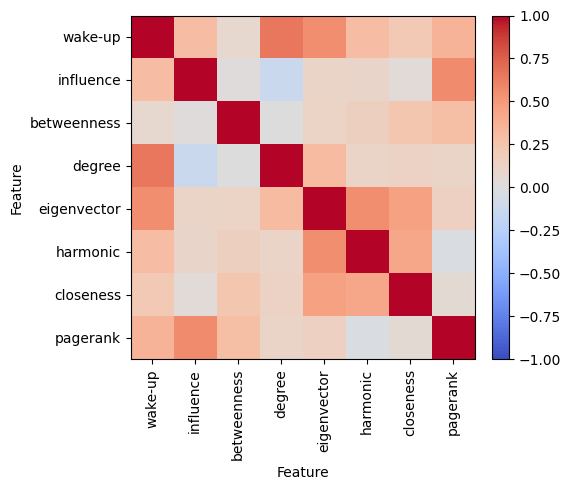

In [401]:
X = [p_star_slp,fried_c, bcent_color, degree2, ecent_color, hcent_color, ccent_color, pagerank_color]
names = ['wake-up', 'influence', 'betweenness', 'degree', 'eigenvector', 'harmonic', 'closeness', 'pagerank']
C = np.corrcoef(X)
plt.figure(figsize=(6, 5))
a = np.nanmax(np.abs(C))
im = plt.imshow(C, cmap="coolwarm", vmin=-a, vmax=a)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.xticks(range(len(names)), names, rotation=90)
plt.yticks(range(len(names)), names)
plt.tight_layout()
plt.show()

#### Comparison of ranking distribution between centralities

Comparison between our centrality measure and the well known ones

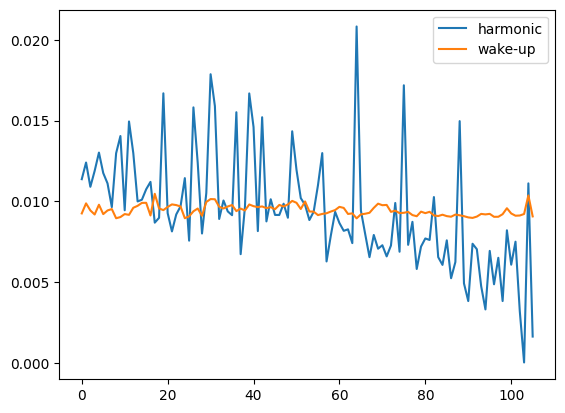

In [402]:
plt.plot(hcent_color, label = 'harmonic')
plt.plot(p_star_slp, label = 'wake-up')
plt.legend()

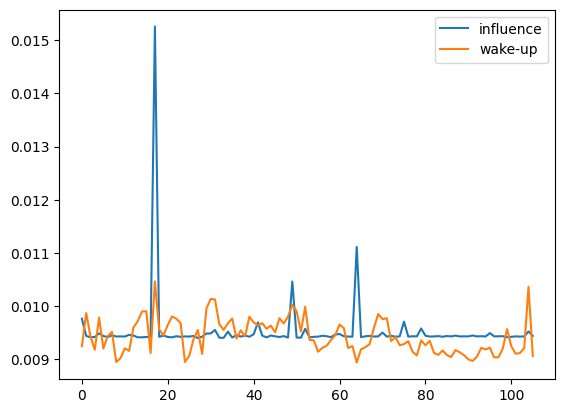

In [403]:
plt.plot(fried_c, label = 'influence')
plt.plot(p_star_slp, label = 'wake-up')
plt.legend()

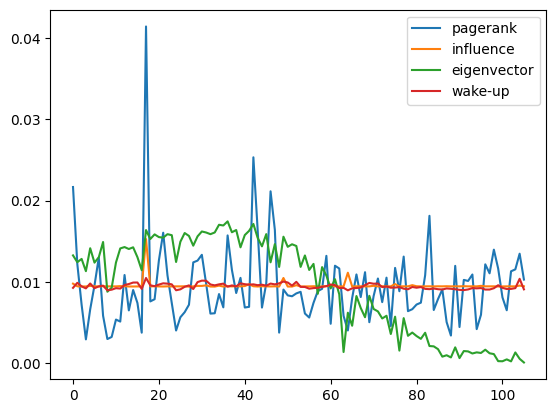

In [404]:
plt.plot(pagerank_color, label='pagerank')
#plt.plot(ccent_color, label = 'closeness')
#plt.plot(bcent_color, label = 'betwenness')
#plt.plot(dcent_color, label = 'degree')
#plt.plot(katz_color, label = 'katz')
plt.plot(fried_c, label = 'influence')
plt.plot(ecent_color, label = 'eigenvector')
#plt.plot(hcent_color, label = 'harmonic')
plt.plot(p_star_slp, label = 'wake-up')
plt.legend()

In [405]:
sigma_h = np.var(hcent_color)
std_h = np.sqrt(sigma_h)
sigma_star = np.var(p_star_slp)
std_star = np.sqrt(sigma_star)
avg_star = np.average(p_star_slp)
avg_h = np.average(hcent_color)
sigma_fried = np.var(fried_c)
std_fried = np.sqrt(sigma_fried)
avg_fried = np.average(fried_c)
np.random.seed(21)
rand_norm_h = np.random.normal(1/N, std_h, N)
rand_norm_star = np.random.normal(1/N, std_star, N)

Cumulative Distribution

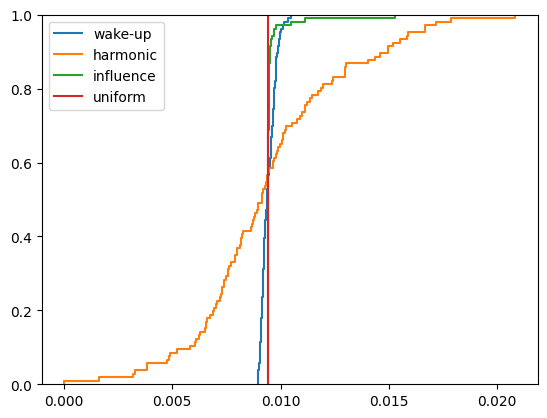

In [406]:
plt.ecdf(p_star_slp, label = 'wake-up')
plt.ecdf(hcent_color, label = 'harmonic') # almost normal sigma .002
plt.ecdf(fried_c,label = 'influence')
plt.ecdf(p_uniform, label='uniform')
#plt.ecdf(rand_norm_star, label = 'normal benchmark influential')
#plt.ecdf(rand_norm_h, label = 'normal benchmark harmonic')
plt.legend()


Normalized Distribution

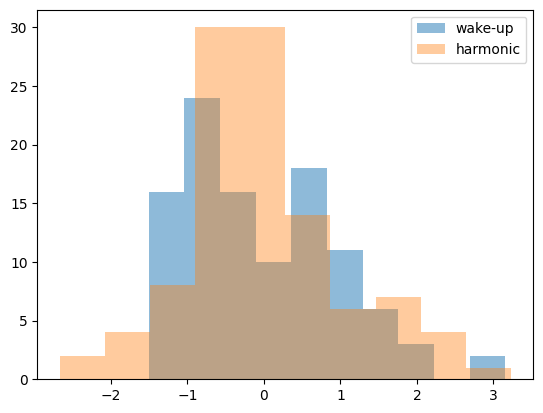

In [407]:
dist_star = (p_star_slp-avg_star*np.ones(N))/std_star
dist_h = (hcent_color-avg_h*np.ones(N))/std_h
dist_fried = (fried_c-avg_fried*np.ones(N))/std_fried
plt.hist(dist_star, label = 'wake-up', alpha = .5)
#plt.hist(dist_fried,label='influence', alpha=.6 )
plt.hist(dist_h, label = 'harmonic', alpha = .4)

plt.legend()

#### Comparison of the dynamics after N iterations

In [408]:
### Comparison after N iterations
print('spectral radius for synchronous system:', spectral_radius(A))
print('lambda_star after N iterations of asynchronous dynamics:',lambda_star_slp**N,(lambda_star_slp**N-lambda_uniform**N)/(lambda_uniform**N),(lambda_star_slp**N - spectral_radius(A))/spectral_radius(A) )
print('lambda_fried after N iterations of asynchronous dynamics:',lambda_fried**N,(lambda_fried**N-lambda_uniform**N)/(lambda_uniform**N),(lambda_fried**N - spectral_radius(A))/spectral_radius(A))
print('lambda_h after N iterations of asynchronous dynamics:',lambda_h**N,(lambda_h**N-lambda_uniform**N)/(lambda_uniform**N),(lambda_h**N - spectral_radius(A))/spectral_radius(A))
print('lambda_unif after N iterations of asynchronous dynamics:',lambda_uniform**N)

spectral radius for synchronous system: 0.10801847916660164
lambda_star after N iterations of asynchronous dynamics: 0.38869221083624267 -0.04802051629702985 2.5983862560844395
lambda_fried after N iterations of asynchronous dynamics: 0.39934081323063636 -0.021940109417345872 2.6969675588073736
lambda_h after N iterations of asynchronous dynamics: 0.9983506626528232 1.4451463700340612 8.24240621008025
lambda_unif after N iterations of asynchronous dynamics: 0.40829893657405714


## Update Dynamics

In [409]:
X_in = np.zeros(N)
agents = [0,5,7, 20, 45, 78]
X_in[agents] = 1
b = np.ones(N)*.8
T = 3000
X_dyn = np.zeros((T+1, N))
X_dyn[0] = X_in
for t in np.arange(T): 
    X_dyn[t+1, :] = avg_update_step(X_dyn[t, :], A, b, p_star_slp)

### COMPARISON HARM###
X_dyn_harm = np.zeros((T+1, N))
X_dyn_harm[0] = X_in
p_comp = hcent_color.copy()
for t in np.arange(T): 
    X_dyn_harm[t+1, :] = avg_update_step(X_dyn_harm[t, :], A, b, p_comp)

### COMPARISON INF###
X_dyn_inf = np.zeros((T+1, N))
X_dyn_inf[0] = X_in
p_comp2 = fried_c.copy()
for t in np.arange(T): 
    X_dyn_inf[t+1, :] = avg_update_step(X_dyn_inf[t, :], A, b, p_comp2)

    ### COMPARISON UNIF###
X_dyn_un = np.zeros((T+1, N))
X_dyn_un[0] = X_in
p_comp3 = p_uniform.copy()
for t in np.arange(T): 
    X_dyn_un[t+1, :] = avg_update_step(X_dyn_un[t, :], A, b, p_comp3)


In [410]:
X_eq = equilibrium(X_in, A, b)

In [411]:
err_wake = np.linalg.norm(X_dyn-X_eq, axis=1)
err_harm = np.linalg.norm(X_dyn_harm-X_eq, axis=1)
err_inf = np.linalg.norm(X_dyn_inf-X_eq, axis=1)
err_un = np.linalg.norm(X_dyn_un-X_eq, axis=1)

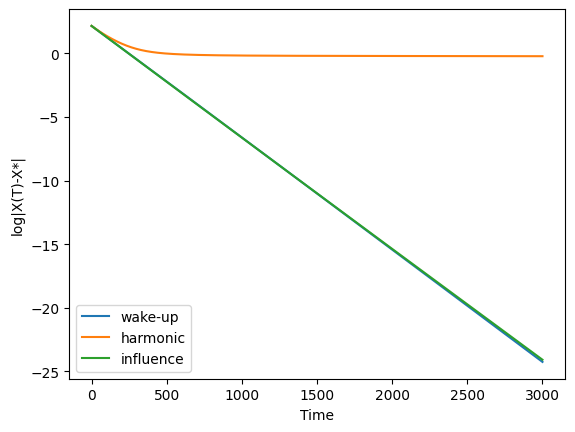

In [412]:
plt.plot(np.log(err_wake), label = 'wake-up')
plt.plot(np.log(err_harm), label = 'harmonic')
plt.plot(np.log(err_inf), label = 'influence')
#plt.plot(np.log(err_un), label = 'uniform')
plt.ylabel('log|X(T)-X*|')
plt.xlabel('Time')
plt.legend()

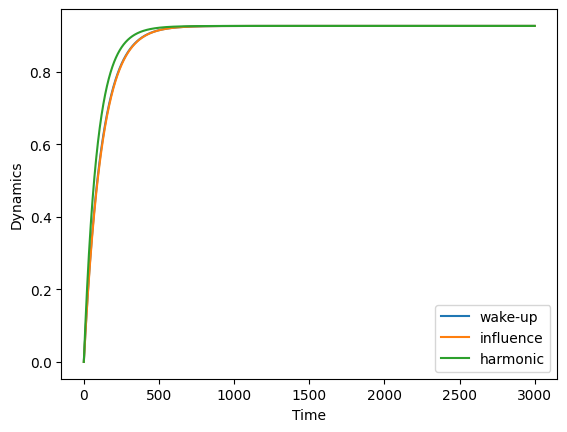

In [413]:
plt.plot(X_dyn[:,4], label = 'wake-up')
plt.plot(X_dyn_inf[:,4], label = 'influence')
plt.plot(X_dyn_harm[:,4], label = 'harmonic')
plt.xlabel('Time')
plt.ylabel('Dynamics')
plt.legend()